In [ ]:
#WE TODAY ARE WORKING ON SEABORN ,PANDAS AND,MATPLOTLIB
# LETS START WITH IMPORTING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#THE MAIN DATA CONTAINS 3 DATA SETS WHER WE TOOK THE MAIN TRAINING DATA SET
sns.set(style="whitegrid")
df = pd.read_csv('train.csv')
df.head()


In [ ]:
df.info()

#TELLS BASIC COLUMN INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:

df.describe()
#DESCRIBES DIFFERENT PARAMETERS LIKE MEAN MINIMUM ETC



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:

df.isnull().sum()
#IDENTIFIES NULL VALUES


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
df.shape

(891, 11)

In [18]:
# Fill missing age with median, and embarked with mode
df['Age'].fillna(df['Age'].median())
df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop cabin due to too many nulls
df.drop(columns=['Cabin'],errors='ignore')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
df.isnull().sum()
#IDENTIFIES NULL VALUES NOW WE HAVE NO NULL VALUES

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [21]:
df['Survived'].value_counts()
#WE CAN SEE 549 DID NOT SURVIVE AND 342 SURVIVED

Survived
0    549
1    342
Name: count, dtype: int64

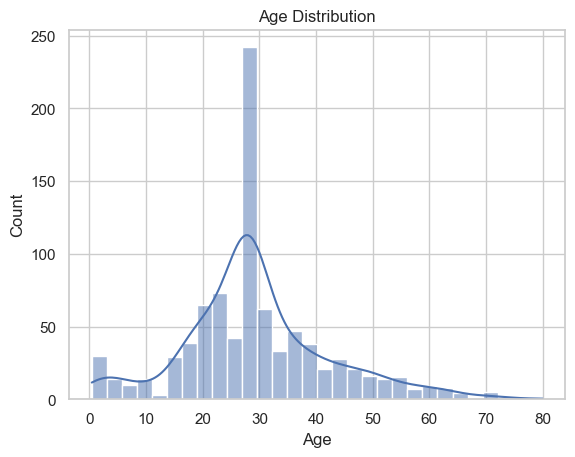

In [ ]:
# Age distribution-UNIVARIABLE ANALYSIS 1
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

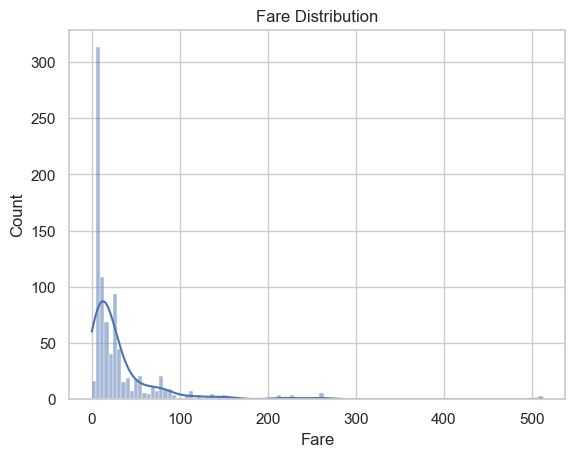

In [ ]:
#UNI VARIABLE ANALYSIS-2 FARE DISTRIBUTION
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

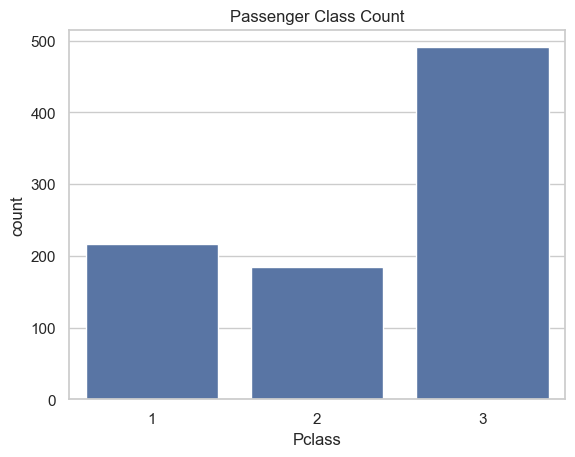

In [ ]:
# Passenger Class-UNI VARIABLE DISTRIBUTION 3
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Count')
plt.show()

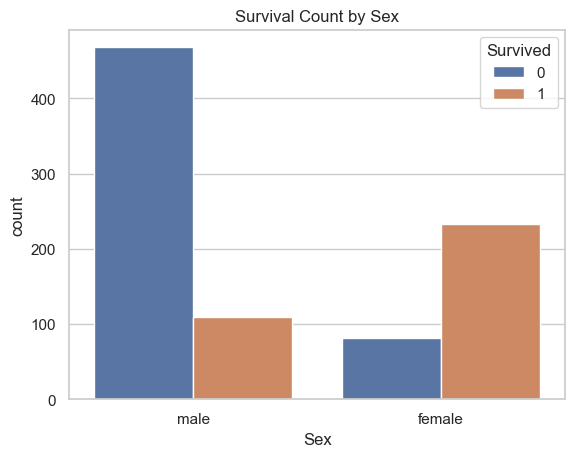

In [25]:
#BI VARIABLE 
# Survival by sex
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.show()

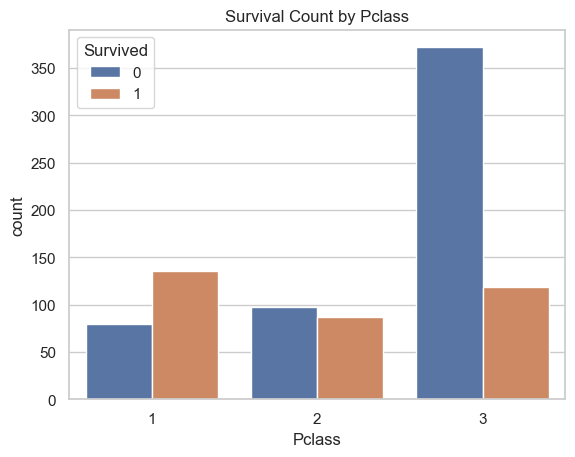

In [26]:
#BI VARIABLE-2
# Survival by class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Pclass')
plt.show()

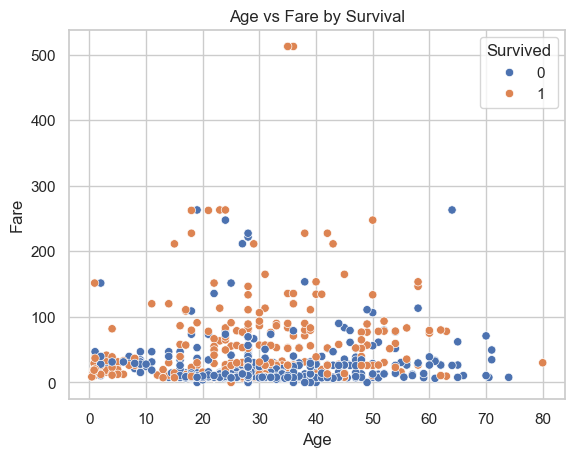

In [27]:
#BI VAR -3
# # Age vs Fare with survival
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare by Survival')
plt.show()

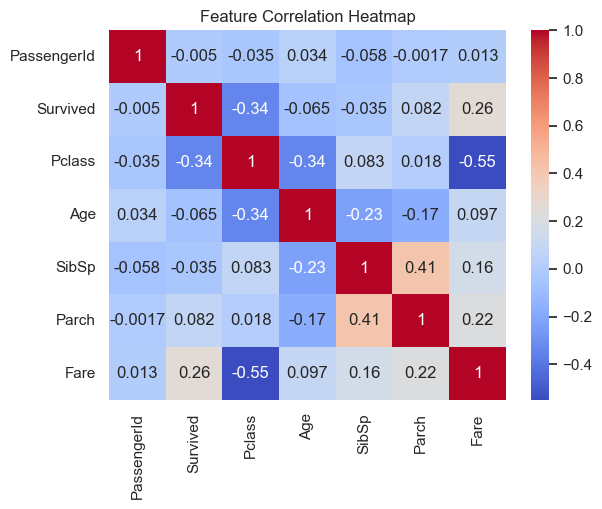

In [29]:
# CORRELATION HEAT MAP
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


In [30]:
               #SUMMARY

#1. Women had much higher survival rate than men.

#2. Passengers in 1st class were more likely to survive.

#3.Younger passengers had slightly better odds.

#4. Higher fares were correlated with survival.

#5. Cabin had too many missing values and was dropped.